### Aufgabe 3.1

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

from scipy.optimize import curve_fit
from uncertainties import ufloat

In [10]:
df = pd.read_excel('data/data.xlsx')

df.set_index("Ordnung", inplace=True)
df = df[df.columns[:3]]

sigma_s = 0.05  # uncertainty of measured values
sigma_l = 0.1   # uncertainty of distances

for col in df.columns:
    df[str(col) + "_u"] = [ufloat(v, sigma_s) for v in df[col]]

for col in df.iloc[:,3:]:
    l = ufloat(col.split("_")[0], sigma_l)
    df[str(col) + "_calc"] = df[col] / l

df = df[df.index > 0]
df.sort_values(by="Ordnung", inplace=True)
df = df[["80_u_calc", "120_u_calc", "160_u_calc"]]
df.head()

,80_u_calc,120_u_calc,160_u_calc
Ordnung,,,
1,0.0037+/-0.0006,0.0033+/-0.0004,0.00375+/-0.00031
2,0.0081+/-0.0006,0.0083+/-0.0004,0.00875+/-0.00031
3,0.0125+/-0.0006,0.0117+/-0.0004,0.01313+/-0.00031
4,0.0163+/-0.0006,0.0158+/-0.0004,0.01688+/-0.00031
5,0.0212+/-0.0006,0.0200+/-0.0004,0.02125+/-0.00031


In [11]:
def linear(x, m, c):
    return m*x + c

df["avg"] = (df["80_u_calc"] + df["120_u_calc"] + df["160_u_calc"])/3

x = df.index.values.astype(float)
y_values = np.array([val.nominal_value for val in df['avg']])
y_errors = np.array([val.std_dev for val in df['avg']])

def linear(x, m, c):
    return m * x + c

popt, pcov = curve_fit(linear, x, y_values, sigma=y_errors, absolute_sigma=True)

# 3. Re-pack into ufloat for your results
m = ufloat(popt[0], np.sqrt(pcov[0,0]))
c = ufloat(popt[1], np.sqrt(pcov[1,1]))

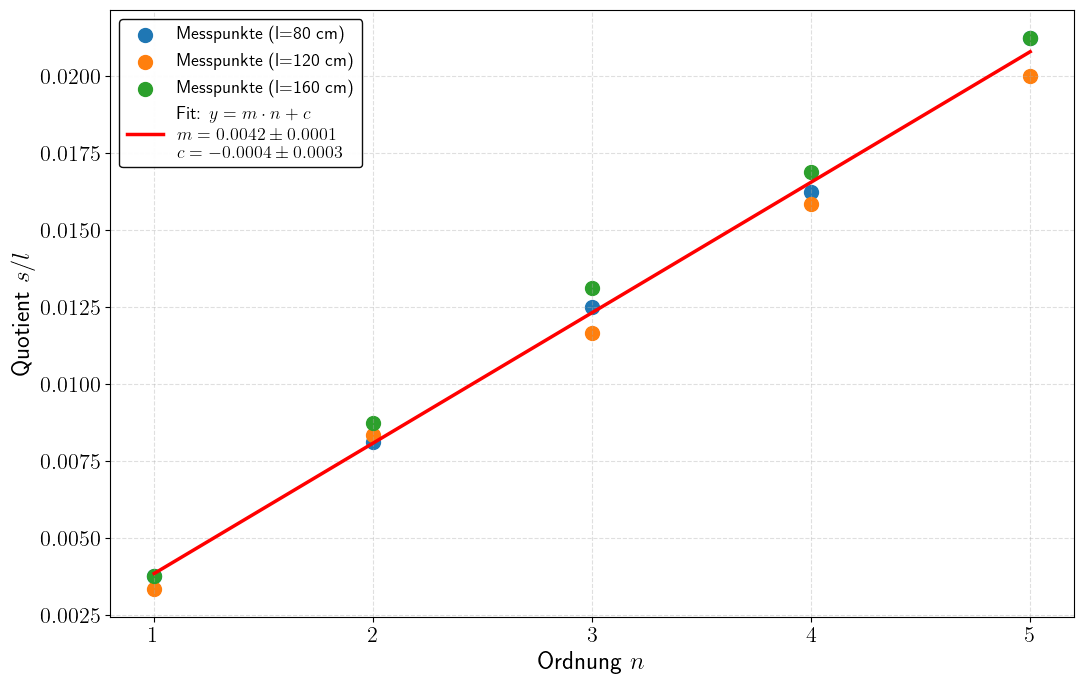

In [15]:
plt.rcParams["text.usetex"] = True
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 13

fig, ax = plt.subplots(figsize=(11, 7))
ax.xaxis.set_major_locator(MultipleLocator(1))

for col in df.columns:
    if col != "avg":
        ax.scatter(df.index, [x.nominal_value for x in df[col]], label=f"Messpunkte (l={col.split('_')[0]} cm)", s=100)

# 2. Plot the regression line with uncertainty shading
x_fit = np.linspace(df.index.min(), df.index.max(), 100)
y_fit = m.nominal_value * x_fit + c.nominal_value

# Calculate the uncertainty of the fit line (simple linear error propagation)
y_fit_err = np.sqrt((x_fit * m.std_dev)**2 + c.std_dev**2)

m_val = f"{m.nominal_value:.4f}"
m_err = f"{m.std_dev:.4f}"
c_val = f"{c.nominal_value:.4f}"
c_err = f"{c.std_dev:.4f}"

fit_label = (f"Fit: $y = m \\cdot n + c$\n"
             f"$m = {m_val} \\pm {m_err}$\n"
             f"$c = {c_val} \\pm {c_err}$")

ax.plot(x_fit, y_fit, "-", color="red", linewidth=2.5, label=fit_label, zorder=5)

ax.legend(loc="best", frameon=True, fontsize=13, framealpha=0.95, edgecolor='black', fancybox=True)
ax.set_xlabel(r"Ordnung $n$", fontsize=18, fontweight='bold')
ax.set_ylabel(r"Quotient $s/l$", fontsize=18, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=16)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# save as svg
fig.savefig("3_1.svg", format="svg", bbox_inches='tight', dpi=150)


In [123]:
print("Results:")
print("m: ", m)
print("c: ", c)

Results:
m:  0.00424+/-0.00009
c:  -0.00039+/-0.00028


In [139]:
lam = ufloat(532.1, 1) * 1e-9
d = lam/m
print(f"{d:.2uP}")

0.0001256±0.0000026
